In [7]:
# Install Swig (required for Box2D physics engine)
!sudo apt-get update && sudo apt-get install -y swig

# Install RL libraries and the Box2D environment
%pip install gymnasium[box2d] stable-baselines3 shimmy matplotlib numpy

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,575 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,087 kB]
Fetched 9,791 kB in 2s (4,052 kB/s)
Reading 

In [8]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import numpy as np
import matplotlib.pyplot as plt


Observation Space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action Space:      Discrete(4)


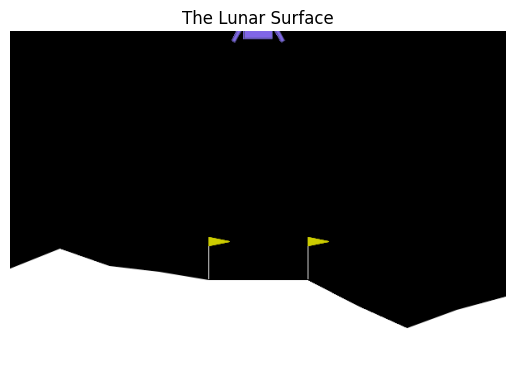

In [9]:
# Create the environment
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env.reset()

print(f"Observation Space: {env.observation_space}")
print(f"Action Space:      {env.action_space}")

# Capture a frame to show the students
plt.imshow(env.render())
plt.axis('off')
plt.title("The Lunar Surface")
plt.show()

env.close()

Using cuda device
Untrained Agent Playing...


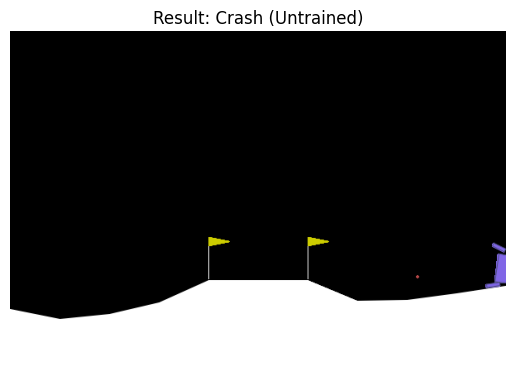

In [10]:

# 1. Create vectorized environment (runs faster)
vec_env = make_vec_env("LunarLander-v3", n_envs=4)

# 2. Initialize PPO with a Multi-Layer Perceptron (Neural Network) policy
model = PPO("MlpPolicy", vec_env, verbose=1)

print("Untrained Agent Playing...")

# Test run
test_env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, info = test_env.reset()
frames = []

for _ in range(100):
    frames.append(test_env.render())
    # Predict action (without learning yet)
    action, _ = model.predict(obs)
    obs, reward, done, truncated, info = test_env.step(action)
    if done or truncated:
        break

test_env.close()

# Show the crash
plt.imshow(frames[-1])
plt.axis('off')
plt.title("Result: Crash (Untrained)")
plt.show()

In [11]:
print("Training started... (This may take 2-5 minutes)")

# We train for 100,000 timesteps.
# In complex physics, the agent needs many tries to understand gravity and inertia.
model.learn(total_timesteps=100000)

print("Training finished!")

# Save the brain
model.save("ppo_lunar_lander")

Training started... (This may take 2-5 minutes)
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 89.4     |
|    ep_rew_mean     | -181     |
| time/              |          |
|    fps             | 1875     |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 8192     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 95.5        |
|    ep_rew_mean          | -158        |
| time/                   |             |
|    fps                  | 931         |
|    iterations           | 2           |
|    time_elapsed         | 17          |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.009276619 |
|    clip_fraction        | 0.0734      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance 

Ace Pilot Landing Sequence Initiated...


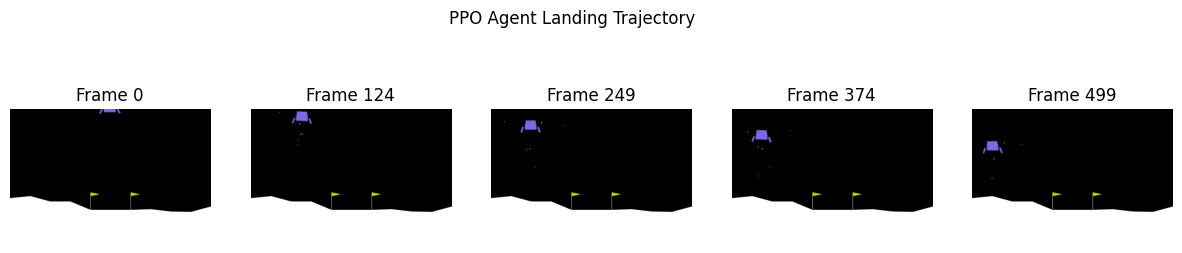

In [12]:
# Load the model
trained_model = PPO.load("ppo_lunar_lander")

# Create environment for visualization
eval_env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, info = eval_env.reset()

frames = []
total_reward = 0

print("Ace Pilot Landing Sequence Initiated...")

for step in range(500):
    frames.append(eval_env.render())

    # deterministic=True makes the agent pick the absolute best move it knows
    action, _ = trained_model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward

    if terminated or truncated:
        frames.append(eval_env.render())
        if reward > 50: # LunarLander gives +100 for a safe landing
            print(f"Outcome: SUCCESS! Safe Landing. Score: {total_reward}")
        else:
            print(f"Outcome: CRASH/Abort. Score: {total_reward}")
        break

eval_env.close()

# --- DISPLAY THE FLIGHT PATH ---
# We will show 5 snapshots of the descent
num_snaps = 5
step_indices = np.linspace(0, len(frames)-1, num_snaps, dtype=int)

fig, axes = plt.subplots(1, num_snaps, figsize=(15, 3))

for i, ax in enumerate(axes):
    frame_idx = step_indices[i]
    ax.imshow(frames[frame_idx])
    ax.axis('off')
    ax.set_title(f"Frame {frame_idx}")

plt.suptitle("PPO Agent Landing Trajectory", y=1.05)
plt.show()